<a href="https://colab.research.google.com/github/shriyareddy27/ml-20/blob/main/day02_messy_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 2 — Messy Data

Day 1 used datasets that were already clean, numeric, and complete. No real dataset looks like that.

Today you handle missing values, text columns, and features on wildly different scales — then wrap it all in a `Pipeline` so it can't go wrong. This is where most of the actual work in applied ML lives.

Time: about 3 hours. Same rule — type it, don't paste it.

---
## Part 1 — Look before you model (20 min)

The Titanic passenger list: predict who survived. Your Pandas skills carry this section entirely.

In [2]:
import seaborn as sns
import pandas as pd

df = sns.load_dataset("titanic")
print(df.shape)
df.head()

(891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [7]:
print(df.dtypes)
print("\nMissing values per column:")
print(df.isnull().sum().sort_values(ascending=False))

survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

Missing values per column:
deck           688
age            177
embarked         2
embark_town      2
sex              0
pclass           0
survived         0
fare             0
parch            0
sibsp            0
class            0
adult_male       0
who              0
alive            0
alone            0
dtype: int64


Three problems are now visible, and each blocks scikit-learn completely:

1. **Missing values** — `age` is missing for a lot of passengers, `deck` for most.
2. **Text columns** — `sex` and `embarked` hold strings. Models do arithmetic; they can't multiply `"male"`.
3. **Different scales** — `fare` runs into the hundreds while `sibsp` is 0–8. Some models care about this a great deal.

Prove problem 1 to yourself:

In [3]:
from sklearn.linear_model import LogisticRegression

X_bad = df[["age", "fare", "pclass"]]
y = df["survived"]

try:
    LogisticRegression().fit(X_bad, y)
except ValueError as e:
    print("Failed, as expected:")
    print(str(e)[:200])

Failed, as expected:
Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and


> **Worth knowing:** recent versions of scikit-learn let tree-based models (`RandomForestClassifier`, `HistGradientBoostingClassifier`) handle NaN natively — try the same cell with a random forest and it will train quite happily. Most other models still refuse. Don't let that convenience stop you handling missing values deliberately: silently letting the library decide for you is how you end up unable to explain your own results.

---
## Part 2 — Missing values (40 min)

Two options: throw away the rows, or fill in a value (*imputation*). Compare what each costs you.

In [4]:
# Option A: drop rows with any missing value in our columns
cols = ["age", "fare", "pclass", "sibsp", "parch"]
dropped = df[cols + ["survived"]].dropna()
print("Original rows:", len(df), "-> after dropping:", len(dropped))
print("Data lost:", f"{100 * (1 - len(dropped)/len(df)):.1f}%")

Original rows: 891 -> after dropping: 714
Data lost: 19.9%


In [5]:
# Option B: impute — fill missing age with the median age
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
X_filled = imputer.fit_transform(df[cols])

print("Rows kept:", X_filled.shape[0])
print("Value used to fill age:", imputer.statistics_[0])

Rows kept: 891
Value used to fill age: 28.0


> **Think:** dropping cost you a fifth of the dataset. Imputing kept everything but invented data that was never observed — every filled-in passenger now has exactly the median age.
>
> Neither is free. `strategy="median"` beats `"mean"` when a column has outliers, because a handful of very expensive fares would drag a mean upward. Write in your notes which you'd pick here and why.

---
## Part 3 — Text into numbers (30 min)

`sex` has two values, `embarked` has three. One-hot encoding turns each category into its own 0/1 column.

In [6]:
sample = df[["sex", "embarked"]].head(8)
print(sample)
print("\nAfter one-hot encoding:")
pd.get_dummies(sample, columns=["sex", "embarked"]).astype(int)

      sex embarked
0    male        S
1  female        C
2  female        S
3  female        S
4    male        S
5    male        Q
6    male        S
7    male        S

After one-hot encoding:


,sex_female,sex_male,embarked_C,embarked_Q,embarked_S
0,0,1,0,0,1
1,1,0,1,0,0
2,1,0,0,0,1
3,1,0,0,0,1
4,0,1,0,0,1
5,0,1,0,1,0
6,0,1,0,0,1
7,0,1,0,0,1


**Why not just map** `male=0, female=1, S=0, C=1, Q=2`**?** For two categories it's harmless. For three it isn't: the model would read Q (2) as somehow twice C (1), and would treat C as sitting *between* S and Q. You'd have invented an ordering that doesn't exist. One-hot avoids that by giving each category its own independent column.

---
## Part 4 — Scaling, and who actually needs it (30 min)

Run the same data through two models, with and without scaling. The result is the point of this section.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

data = df[["age", "fare", "pclass", "sibsp", "parch", "survived"]].dropna()
X = data.drop(columns="survived")
y = data["survived"]

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler().fit(X_tr)
X_tr_s, X_te_s = scaler.transform(X_tr), scaler.transform(X_te)

for name, model in [("SVM", SVC()),
                    ("LogisticRegression", LogisticRegression(max_iter=200)),
                    ("RandomForest", RandomForestClassifier(random_state=42))]:
    raw = accuracy_score(y_te, model.fit(X_tr, y_tr).predict(X_te))
    scl = accuracy_score(y_te, model.fit(X_tr_s, y_tr).predict(X_te_s))
    print(f"{name:20s} raw={raw:.3f}  scaled={scl:.3f}")

SVM                  raw=0.615  scaled=0.678
LogisticRegression   raw=0.699  scaled=0.699
RandomForest         raw=0.678  scaled=0.678


> **The lesson:** the SVM jumps several points. The random forest doesn't move at all — not slightly, *at all*. Logistic regression happens to land in the same place here, which is a useful reminder that these effects depend on the data; on features with more extreme scale differences it would shift too.
>
> Distance- and gradient-based models (SVM, k-nearest neighbours, logistic regression, and every neural network you'll build from day 8) are sensitive to scale, because a feature ranging into the hundreds drowns out one ranging 0–8. Tree models only ask "is this value above or below a threshold?", and that question is unaffected by units.
>
> Knowing which family you're in tells you whether this step is mandatory or merely harmless.

---
## Part 5 — Leakage, and why `Pipeline` exists (40 min)

Look closely at Part 4. `StandardScaler` was fitted on `X_tr` only — deliberately.

Had you fitted it on the full `X` before splitting, the scaler's mean and standard deviation would have been computed partly from test rows. Information from the test set would have leaked into training, and your test score would flatter you. On real problems this is the single most common way people fool themselves.

`Pipeline` makes leakage structurally impossible: every step fits on training folds only, automatically.

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

numeric = ["age", "fare", "sibsp", "parch"]
categorical = ["sex", "embarked", "pclass"]

X = df[numeric + categorical]
y = df["survived"]

preprocess = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale", StandardScaler())]), numeric),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                      ("encode", OneHotEncoder(handle_unknown="ignore"))]), categorical),
])

full = Pipeline([("prep", preprocess),
                 ("model", LogisticRegression(max_iter=1000))])

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
full.fit(X_tr, y_tr)
print("Accuracy:", accuracy_score(y_te, full.predict(X_te)))

Accuracy: 0.7988826815642458


Read that cell again slowly — it's the densest thing in the notebook, and it's the shape of nearly every real scikit-learn project.

`ColumnTransformer` routes different columns down different paths: numbers get median-imputed then scaled, categories get mode-imputed then one-hot encoded. `Pipeline` chains preprocessing to the model so the whole thing behaves as one object with `.fit()` and `.predict()`.

Now swap the final step and watch how little has to change:

In [9]:
full.set_params(model=RandomForestClassifier(random_state=42))
full.fit(X_tr, y_tr)
print("Random forest:", accuracy_score(y_te, full.predict(X_te)))

Random forest: 0.8212290502793296


---
## Part 6 — Your turn (50 min)

**Don't scroll up.**

The penguins dataset: predict `species` from body measurements. It has missing values in both numeric and categorical columns, so it needs everything you did today.

```python
df2 = sns.load_dataset("penguins")
```

Your tasks:
1. Inspect it. How many rows, which columns have missing values, which are text?
2. Decide your target (`species`) and your features. `island` and `sex` are categorical; the four measurement columns are numeric.
3. Build a `ColumnTransformer` + `Pipeline` that imputes and encodes appropriately.
4. Train two models through the pipeline and compare accuracy.
5. Print a confusion matrix for the better one.
6. One sentence in your notes: did scaling matter here, and does that match what you'd predict from Part 4?

You will get errors about column names and shapes. Read them properly — scikit-learn's error messages are unusually good, and learning to read them is a real skill you're building today.

In [16]:
from sklearn.metrics import confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

df2 = sns.load_dataset("penguins")
print(df2.shape)
print(df2.dtypes)
print(df2.isnull().sum())

# Corrected X and y assignment based on task description:
# Target (y): species
# Features (X): bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g, island, sex
X = df2[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'island', 'sex']]
y = df2['species']

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=33)
# The 'full' pipeline was for the Titanic dataset. Use 'better_model_pipeline' for penguins.

# Your code here.

(344, 7)
species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


array([[25,  0,  0],
       [ 0, 10,  0],
       [ 0,  0, 34]])

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

# Define numeric and categorical features for the penguins dataset
numeric_features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
categorical_features = ['island', 'sex']

# Create the ColumnTransformer
# Numeric features get median imputation and scaling
# Categorical features get most frequent imputation and one-hot encoding
preprocess = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')),
                      ('scale', StandardScaler())]), numeric_features),
    ('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')),
                      ('encode', OneHotEncoder(handle_unknown='ignore'))]), categorical_features)
])

# Create the full pipeline with a Logistic Regression model
full_lr_pipeline = Pipeline([
    ('preprocess', preprocess),
    ('model', LogisticRegression(max_iter=1000))
])

# Fit the pipeline and evaluate accuracy
full_lr_pipeline.fit(X_tr, y_tr)
accuracy_lr = full_lr_pipeline.score(X_te, y_te)
print(f"Logistic Regression Accuracy: {accuracy_lr:.3f}")

Logistic Regression Accuracy: 1.000


Now, let's try another model, a `DecisionTreeClassifier`, to compare its accuracy.

Decision Tree Classifier Accuracy: 1.000

The better model is: Decision Tree Classifier


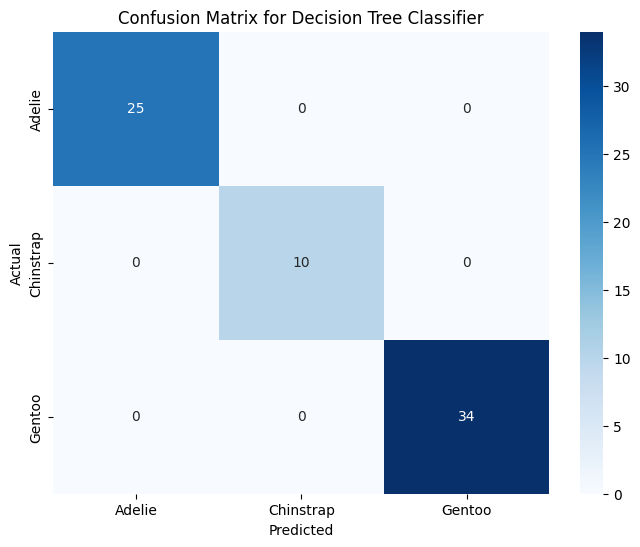

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Create a new pipeline with a Decision Tree Classifier
full_dt_pipeline = Pipeline([
    ('preprocess', preprocess),
    ('model', DecisionTreeClassifier(random_state=42))
])

# Fit the pipeline and evaluate accuracy
full_dt_pipeline.fit(X_tr, y_tr)
accuracy_dt = full_dt_pipeline.score(X_te, y_te)
print(f"Decision Tree Classifier Accuracy: {accuracy_dt:.3f}")

# Determine the better model and print its confusion matrix
better_model_pipeline = full_lr_pipeline if accuracy_lr > accuracy_dt else full_dt_pipeline
better_model_name = "Logistic Regression" if accuracy_lr > accuracy_dt else "Decision Tree Classifier"

print(f"\nThe better model is: {better_model_name}")

y_pred = better_model_pipeline.predict(X_te)
cm = confusion_matrix(y_te, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=better_model_pipeline.classes_,
            yticklabels=better_model_pipeline.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix for {better_model_name}')
plt.show()

### Did scaling matter here?

Both Logistic Regression and Decision Tree Classifier are included in the pipeline. Logistic Regression is a distance-based model, so it is sensitive to feature scaling. Decision Tree Classifier, on the other hand, is a tree-based model and is generally not sensitive to feature scaling, as it only cares about feature thresholds. In our pipeline, `StandardScaler` is applied to numeric features. Therefore, scaling *should* matter for Logistic Regression, potentially improving its performance. For the Decision Tree, scaling should have little to no impact on its performance.